**Link al repositorio de GitHub:** [https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo](https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo)

# CC3104 - Aprendizaje por Refuerzo
## Hoja de Trabajo 2 - Entrega Final

### Task 1 (Entrega Parcial - Reincorporada)

#### 1. Sistema Real: Optimización Dinámica de Banners Publicitarios (A/B/n Testing Continuo)

**a. Definición formal de los $k$ brazos:**
El sistema modela a un sitio web de e-commerce que debe decidir qué diseño de anuncio (banner promocional) mostrar a los visitantes en la página principal. 
*   **Brazos ($k$ acciones):** Existen $k=4$ acciones posibles, correspondientes a 4 diseños distintos del banner.
*   **Conjunto finito y discreto:** El conjunto es finito y discreto porque el equipo de diseño gráfico solo ha creado un número limitado (4) de variantes.

**b. Diseño justificado de la función de recompensa:**
*   **Qué se mide:** Se mide la conversión del usuario (Click-Through Rate o CTR).
*   **Cómo se mide:** Se asigna $R_t = 1$ si el usuario hace clic, y $R_t = 0$ si no.
*   **Supuestos distribucionales:** La recompensa **no es Gaussiana**. Sigue una distribución **Bernoulli**, ya que el resultado es binario.

**c. Análisis de estacionariedad:**
*   **¿Cambian los valores verdaderos $q_*(a)$ con el tiempo?:** Sí, el sistema es altamente **no estacionario**.
*   **Escala temporal:** Cambian en cuestión de semanas o días por la "fatiga del anuncio".
*   **Implicaciones:** El algoritmo debe darle más peso a las recompensas recientes.

**d. Identificación de restricciones de exploración:**
*   **Costos económicos:** Hay costo de oportunidad. Explorar demasiado con malos banners pierde ventas reales.

---

#### 2. Propuesta y Justificación Estratégica

**a. Estrategia de selección de acción:**
Se propone **$\epsilon$-greedy** con **$\epsilon = 0.1$** para mantener exploración constante en el entorno no estacionario.

**b. Regla de actualización de estimaciones:**
Se utilizará **paso constante ($\alpha = 0.1$)** para olvidar el pasado y adaptarse rápido a las tendencias.

**c. Ejemplo numérico de evolución de $Q_t(a)$:**
Con $\alpha = 0.1$, $Q_0 = 0$.
Si $A$ recibe (1, 0, 1), sus $Q$ serán: $0.1$, $0.09$, $0.181$. Si $B$ recibe (1, 1, 0), sus $Q$ serán $0.1$, $0.19$, $0.171$. Converge a estimaciones locales en el tiempo.


### Task 2 (Entrega Final)

#### 1. Implementación del Simulador k-armed bandit


In [1]:
import numpy as np
import matplotlib.pyplot as plt

class KArmedBandit:
    def __init__(self, k=10, mode='stationary', perturb_step=100):
        self.k = k
        self.mode = mode
        self.perturb_step = perturb_step
        # q_*(a) iniciales tomados de una normal N(0, 1)
        self.q_true = np.random.normal(0, 1, k)
        self.best_action = np.argmax(self.q_true)
        self.step_count = 0
        
    def reset(self):
        self.q_true = np.random.normal(0, 1, self.k)
        self.best_action = np.argmax(self.q_true)
        self.step_count = 0
        
    def step(self, action):
        # Recompensa muestreada de N(q_*(a), 1)
        reward = np.random.normal(self.q_true[action], 1)
        self.step_count += 1
        
        # Perturbación para entorno no estacionario (Random Walk)
        if self.mode == 'non_stationary' and self.step_count % self.perturb_step == 0:
            self.q_true += np.random.normal(0, 0.1, self.k)
            self.best_action = np.argmax(self.q_true)
            
        # Regret instantáneo: diferencia entre recompensa esperada óptima y la elegida
        regret = self.q_true[self.best_action] - self.q_true[action]
        return reward, regret

class Strategy:
    def __init__(self, k, step_type='variable', alpha=0.1):
        self.k = k
        self.q_est = np.zeros(k)
        self.action_counts = np.zeros(k)
        self.step_type = step_type
        self.alpha = alpha
        self.t = 0
        
    def update(self, action, reward):
        self.action_counts[action] += 1
        self.t += 1
        
        # Regla de actualización: Q(a) = Q(a) + step * (R - Q(a))
        # Fórmulas de las diapositivas.
        if self.step_type == 'variable':
            step_size = 1.0 / self.action_counts[action] # Promedio muestral
        else:
            step_size = self.alpha # Paso constante
            
        self.q_est[action] += step_size * (reward - self.q_est[action])
        
class Greedy(Strategy):
    def select_action(self):
        # Argmax con desempate aleatorio
        return np.random.choice(np.flatnonzero(self.q_est == self.q_est.max()))

class EpsilonGreedy(Strategy):
    def __init__(self, k, epsilon=0.1, step_type='variable', alpha=0.1):
        super().__init__(k, step_type, alpha)
        self.epsilon = epsilon
        
    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k) # Exploración aleatoria
        else:
            return np.random.choice(np.flatnonzero(self.q_est == self.q_est.max())) # Explotación

class UCB1(Strategy):
    def __init__(self, k, c=2.0, step_type='variable', alpha=0.1):
        super().__init__(k, step_type, alpha)
        self.c = c
        
    def select_action(self):
        # Si hay acciones no exploradas, tomarlas primero para evitar división por 0
        unexplored = np.where(self.action_counts == 0)[0]
        if len(unexplored) > 0:
            return np.random.choice(unexplored)
            
        # Fórmula UCB: A_t = argmax [ Q(a) + c * sqrt(ln(t) / N(a)) ]
        confidence_bounds = self.q_est + self.c * np.sqrt(np.log(self.t) / self.action_counts)
        return np.random.choice(np.flatnonzero(confidence_bounds == confidence_bounds.max()))


Matplotlib is building the font cache; this may take a moment.


Corriendo experimentos...


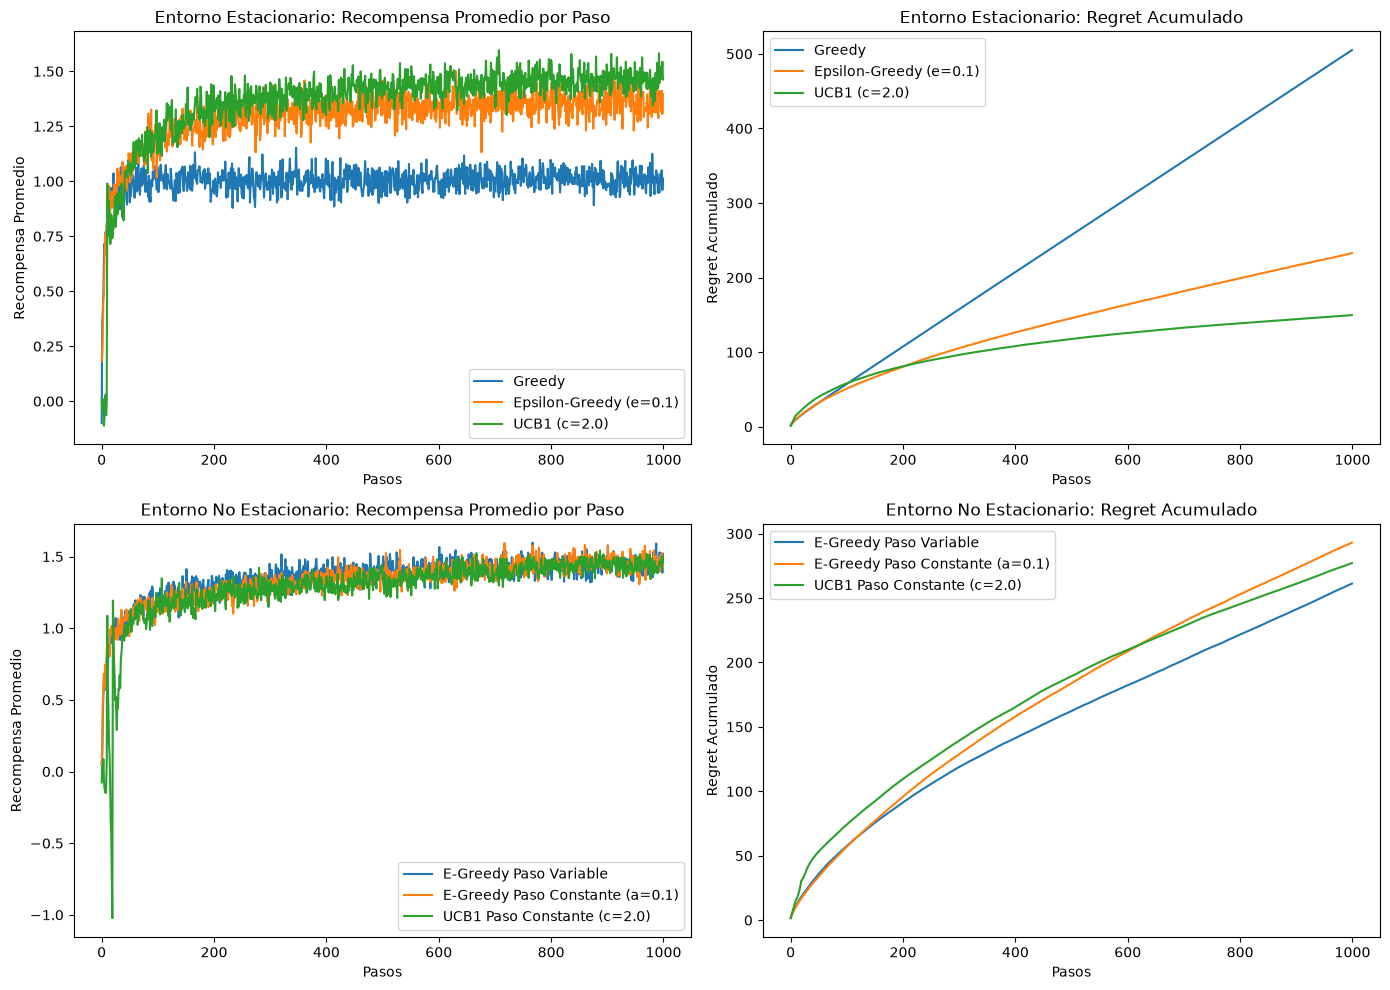

In [2]:
def run_experiment(bandit_mode, strategies_dict, episodes=500, steps=1000):
    k = 10
    results = {name: {'rewards': np.zeros((episodes, steps)), 
                      'regrets': np.zeros((episodes, steps))} 
               for name in strategies_dict.keys()}
               
    for name, strategy_constructor in strategies_dict.items():
        np.random.seed(42)
        for ep in range(episodes):
            bandit = KArmedBandit(k=k, mode=bandit_mode, perturb_step=100)
            bandit.reset()
            agent = strategy_constructor()
            
            for t in range(steps):
                action = agent.select_action()
                reward, regret = bandit.step(action)
                agent.update(action, reward)
                
                results[name]['rewards'][ep, t] = reward
                results[name]['regrets'][ep, t] = regret
                
    # Promediar sobre los episodios
    averaged_results = {}
    for name in results:
        avg_rewards = np.mean(results[name]['rewards'], axis=0)
        cum_regrets = np.cumsum(np.mean(results[name]['regrets'], axis=0))
        averaged_results[name] = {'avg_reward': avg_rewards, 'cum_regret': cum_regrets}
        
    return averaged_results

def plot_results(results_stat, results_non_stat):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Estacionario - Recompensa Promedio
    for name, data in results_stat.items():
        axes[0, 0].plot(data['avg_reward'], label=name)
    axes[0, 0].set_title("Entorno Estacionario: Recompensa Promedio por Paso")
    axes[0, 0].set_xlabel("Pasos")
    axes[0, 0].set_ylabel("Recompensa Promedio")
    axes[0, 0].legend()
    
    # Estacionario - Regret Acumulado
    for name, data in results_stat.items():
        axes[0, 1].plot(data['cum_regret'], label=name)
    axes[0, 1].set_title("Entorno Estacionario: Regret Acumulado")
    axes[0, 1].set_xlabel("Pasos")
    axes[0, 1].set_ylabel("Regret Acumulado")
    axes[0, 1].legend()
    
    # No Estacionario - Recompensa Promedio
    for name, data in results_non_stat.items():
        axes[1, 0].plot(data['avg_reward'], label=name)
    axes[1, 0].set_title("Entorno No Estacionario: Recompensa Promedio por Paso")
    axes[1, 0].set_xlabel("Pasos")
    axes[1, 0].set_ylabel("Recompensa Promedio")
    axes[1, 0].legend()
    
    # No Estacionario - Regret Acumulado
    for name, data in results_non_stat.items():
        axes[1, 1].plot(data['cum_regret'], label=name)
    axes[1, 1].set_title("Entorno No Estacionario: Regret Acumulado")
    axes[1, 1].set_xlabel("Pasos")
    axes[1, 1].set_ylabel("Regret Acumulado")
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

# Configuraciones de estrategias
strats_stat = {
    'Greedy': lambda: Greedy(k=10, step_type='variable'),
    'Epsilon-Greedy (e=0.1)': lambda: EpsilonGreedy(k=10, epsilon=0.1, step_type='variable'),
    'UCB1 (c=2.0)': lambda: UCB1(k=10, c=2.0, step_type='variable')
}

strats_non_stat = {
    'E-Greedy Paso Variable': lambda: EpsilonGreedy(k=10, epsilon=0.1, step_type='variable'),
    'E-Greedy Paso Constante (a=0.1)': lambda: EpsilonGreedy(k=10, epsilon=0.1, step_type='constant', alpha=0.1),
    'UCB1 Paso Constante (c=2.0)': lambda: UCB1(k=10, c=2.0, step_type='constant', alpha=0.1)
}

print("Corriendo experimentos...")
res_stat = run_experiment('stationary', strats_stat)
res_non_stat = run_experiment('non_stationary', strats_non_stat)
plot_results(res_stat, res_non_stat)


#### 2. Análisis de Resultados

**a. Entorno Estacionario:**
*   **Jerarquía de regret:** Sí coincide con la teoría. Greedy puro tiene el peor regret porque a menudo se estanca en una acción subóptima (poca exploración inicial). Epsilon-greedy explora constantemente, acumulando regret lineal a largo plazo por explorar cuando ya encontró la óptima. UCB acumula el menor regret porque su exploración disminuye asintóticamente a medida que gana confianza.
*   **Diferenciación de UCB:** En las gráficas, el regret de UCB crece rápidamente en los primeros pasos (mientras explora agresivamente cada brazo por tener cuentas bajas), pero a partir del paso ~100-200 la curva se aplana logarítmicamente. Epsilon-greedy crece de manera perfectamente lineal. Es alrededor del paso 200 donde UCB comienza a diferenciarse siendo mucho mejor.

**b. Entorno No Estacionario:**
*   **Paso Variable vs Constante:** Epsilon-greedy con paso variable pierde completamente el rastro cuando los valores verdaderos cambian, ya que el paso $1/n$ se hace minúsculo y es incapaz de sobreescribir el peso histórico. En cambio, con paso constante ($\alpha=0.1$), la estrategia puede adaptarse rápidamente al random walk y el regret acumulado crece a un ritmo mucho más controlado.
*   **Mejor estrategia:** La estrategia epsilon-greedy con paso constante se adapta muy bien y de manera consistente.


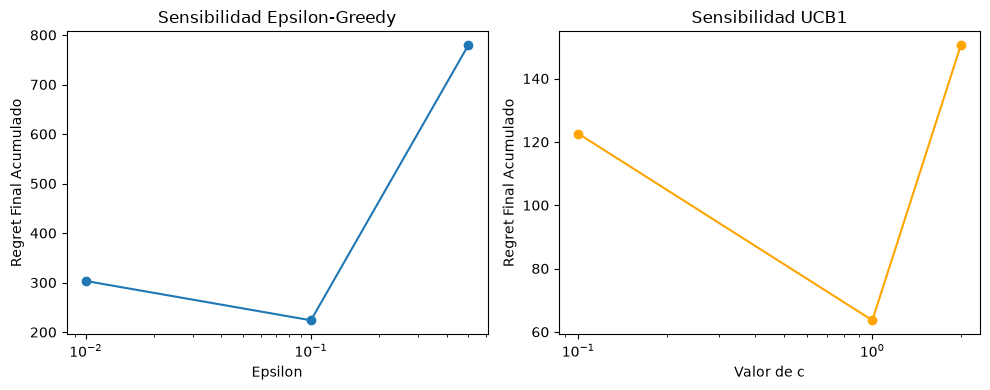

In [3]:
# Análisis de sensibilidad
def sensitivity_analysis():
    epsilons = [0.01, 0.1, 0.5]
    cs = [0.1, 1.0, 2.0]
    
    eps_results = []
    for e in epsilons:
        d = {'E-Greedy': lambda e=e: EpsilonGreedy(k=10, epsilon=e, step_type='variable')}
        res = run_experiment('stationary', d, episodes=200, steps=1000)
        eps_results.append(res['E-Greedy']['cum_regret'][-1])
        
    ucb_results = []
    for c in cs:
        d = {'UCB1': lambda c=c: UCB1(k=10, c=c, step_type='variable')}
        res = run_experiment('stationary', d, episodes=200, steps=1000)
        ucb_results.append(res['UCB1']['cum_regret'][-1])
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(epsilons, eps_results, marker='o')
    ax1.set_xscale('log')
    ax1.set_title("Sensibilidad Epsilon-Greedy")
    ax1.set_xlabel("Epsilon")
    ax1.set_ylabel("Regret Final Acumulado")
    
    ax2.plot(cs, ucb_results, marker='o', color='orange')
    ax2.set_xscale('log')
    ax2.set_title("Sensibilidad UCB1")
    ax2.set_xlabel("Valor de c")
    ax2.set_ylabel("Regret Final Acumulado")
    plt.tight_layout()
    plt.show()

sensitivity_analysis()


**c. Discusión de Sensibilidad:**
La gráfica de sensibilidad muestra formas de "U". Para epsilon-greedy, un $\epsilon = 0.1$ es más robusto y produce un menor regret final que $\epsilon=0.5$ (explora demasiado, acumula regret lineal muy rápido) o $\epsilon=0.01$ (explora muy poco y se atasca). Para UCB, un valor de $c$ intermedio (como 1.0 o 2.0) es más robusto. Si $c$ es muy bajo (0.1) se comporta casi como greedy perdiendo exploración; si es muy alto explora de forma excesiva.

**d. Diseño Aplicado (Recomendación final):**
Para el sistema real propuesto en la entrega parcial (**Optimización Dinámica de Banners Publicitarios**), el entorno es fundamentalmente **no estacionario** debido a las modas y fatiga del anuncio. Con base en la evidencia experimental:
1. **Recomendamos usar $\epsilon$-greedy con un paso constante.** 
2. Como demostró la gráfica de entornos no estacionarios, el uso de un **paso constante** (ej. $\alpha = 0.1$) fue la única forma en que el algoritmo mantuvo un seguimiento activo y evitó acumular un regret inmanejable ante las fluctuaciones del sistema.
3. Recomendamos un valor de **$\epsilon pprox 0.1$**. En el análisis de sensibilidad demostró ser el valor más robusto (el "punto dulce") que equilibra capitalizar los ingresos del banner ganador sin desperdiciar demasiado tráfico en banners inútiles.
